In [1]:
import os
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from dna_features_viewer import GraphicFeature, GraphicRecord

cwd = os.getcwd()
if cwd.endswith('bacteriocins'):
    os.chdir('../..')
    cwd = os.getcwd()

In [2]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('data')
assert data_folder.is_dir()

nocardithiocin_folder = Path('data/amp_db/Nocardithiocin')
assert nocardithiocin_folder.is_dir()

In [3]:
gtdb_metadata = pd.read_csv(data_folder / 'amp_db' / 'gtdb_metadata.csv.gz', index_col='ncbi_accession')

In [4]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(metadata : str):
        m = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv['metadata'].apply(parse_protein_id)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True).set_index('protein_id')


In [5]:
nocardia_pseudobrasiliensis_gff = parse_gff(nocardithiocin_folder / 'Nocardia pseudobrasiliensis DSM 44290' / 'GCF_003350585.1_ASM335058v1_genomic.gff')
nocardia_pseudobrasiliensis_gff.head()

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_211335693.1,NZ_QQBC01000001.1,GeneMarkS-2+,CDS,1,478,.,+,1,ID=cds-WP_211335693.1;Parent=gene-DFR76_RS0000...,hypothetical protein
WP_068001980.1,NZ_QQBC01000001.1,Protein Homology,CDS,685,1707,.,-,0,ID=cds-WP_068001980.1;Parent=gene-DFR76_RS0001...,NADP-dependent oxidoreductase
WP_068002133.1,NZ_QQBC01000001.1,Protein Homology,CDS,1985,2824,.,-,0,ID=cds-WP_068002133.1;Parent=gene-DFR76_RS0001...,patatin-like phospholipase family protein
WP_147287798.1,NZ_QQBC01000001.1,Protein Homology,CDS,2956,4407,.,+,0,ID=cds-WP_147287798.1;Parent=gene-DFR76_RS0002...,FAD-dependent oxidoreductase
WP_156524939.1,NZ_QQBC01000001.1,GeneMarkS-2+,CDS,4404,4571,.,-,0,ID=cds-WP_156524939.1;Parent=gene-DFR76_RS3994...,hypothetical protein


In [6]:
precursor = nocardia_pseudobrasiliensis_gff.loc['WP_067999479.1']
precursor

contig_id                                      NZ_QQBC01000004.1
source                                          Protein Homology
type                                                         CDS
start                                                     196296
end                                                       196475
na1                                                            .
strand                                                         -
na2                                                            0
metadata       ID=cds-WP_067999479.1;Parent=gene-DFR76_RS1381...
description    thiomuracin/GE37468 family thiazolyl RiPP peptide
Name: WP_067999479.1, dtype: object

In [7]:
n_upstream = n_downstream = 9_000
contig_id = precursor['contig_id']
start = max(precursor['start'] - n_upstream, 1)
end = precursor['end'] + n_downstream

nocardithiocin_context = nocardia_pseudobrasiliensis_gff[
    (nocardia_pseudobrasiliensis_gff['contig_id'] == contig_id) &
    (nocardia_pseudobrasiliensis_gff['start'] >= start) &
    (nocardia_pseudobrasiliensis_gff['start'] < end) &
    (nocardia_pseudobrasiliensis_gff['end'] > start) &
    (nocardia_pseudobrasiliensis_gff['end'] <= end)
].copy()
nocardithiocin_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_067999495.1,NZ_QQBC01000004.1,Protein Homology,CDS,187504,188526,.,+,0,ID=cds-WP_067999495.1;Parent=gene-DFR76_RS1377...,polyprenyl synthetase family protein
WP_067999493.1,NZ_QQBC01000004.1,Protein Homology,CDS,188750,189622,.,+,0,ID=cds-WP_067999493.1;Parent=gene-DFR76_RS1378...,zinc metalloprotease HtpX
WP_147287926.1,NZ_QQBC01000004.1,Protein Homology,CDS,189737,190840,.,+,0,ID=cds-WP_147287926.1;Parent=gene-DFR76_RS1378...,thiopeptide maturation pyridine synthase
WP_067999487.1,NZ_QQBC01000004.1,GeneMarkS-2+,CDS,190841,192691,.,+,0,ID=cds-WP_067999487.1;Parent=gene-DFR76_RS1379...,hypothetical protein
WP_255285523.1,NZ_QQBC01000004.1,Protein Homology,CDS,192712,193311,.,-,0,ID=cds-WP_255285523.1;Parent=gene-DFR76_RS1379...,class I SAM-dependent methyltransferase
WP_067999484.1,NZ_QQBC01000004.1,Protein Homology,CDS,193360,193857,.,-,0,ID=cds-WP_067999484.1;Parent=gene-DFR76_RS4030...,response regulator transcription factor
WP_067999483.1,NZ_QQBC01000004.1,Protein Homology,CDS,194100,195026,.,-,0,ID=cds-WP_067999483.1;Parent=gene-DFR76_RS1380...,class I SAM-dependent methyltransferase
WP_169813766.1,NZ_QQBC01000004.1,Protein Homology,CDS,194995,196080,.,-,0,ID=cds-WP_169813766.1;Parent=gene-DFR76_RS1381...,cytochrome P450
WP_067999479.1,NZ_QQBC01000004.1,Protein Homology,CDS,196296,196475,.,-,0,ID=cds-WP_067999479.1;Parent=gene-DFR76_RS1381...,thiomuracin/GE37468 family thiazolyl RiPP peptide


In [8]:
protein_id_description_map = {
    'WP_147287926.1': 'Dehydratase',
    'WP_067999487.1': 'Cyclodehydratase / peptidase',
    'WP_255285523.1': 'Methyltransferase',
    'WP_067999484.1': 'Transcription factor',
    'WP_067999483.1': 'Methyltransferase',
    'WP_169813766.1': 'P450 monooxygenase',
    'WP_067999479.1': 'Nocardithiocin precursor peptide',
    'WP_211335851.1': 'P450 monooxygenase',
    'WP_067999477.1': 'Dehydratase',
    'WP_067999475.1': 'Dehydratase',
    'WP_067999473.1': 'Dehydrogenase',
    'WP_067999472.1': 'Cyclodehydratase',
}
for protein_id, description in protein_id_description_map.items():
    nocardithiocin_context.loc[protein_id, 'description'] = description

In [9]:
nocardithiocin_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_067999495.1,NZ_QQBC01000004.1,Protein Homology,CDS,187504,188526,.,+,0,ID=cds-WP_067999495.1;Parent=gene-DFR76_RS1377...,polyprenyl synthetase family protein
WP_067999493.1,NZ_QQBC01000004.1,Protein Homology,CDS,188750,189622,.,+,0,ID=cds-WP_067999493.1;Parent=gene-DFR76_RS1378...,zinc metalloprotease HtpX
WP_147287926.1,NZ_QQBC01000004.1,Protein Homology,CDS,189737,190840,.,+,0,ID=cds-WP_147287926.1;Parent=gene-DFR76_RS1378...,Dehydratase
WP_067999487.1,NZ_QQBC01000004.1,GeneMarkS-2+,CDS,190841,192691,.,+,0,ID=cds-WP_067999487.1;Parent=gene-DFR76_RS1379...,Cyclodehydratase / peptidase
WP_255285523.1,NZ_QQBC01000004.1,Protein Homology,CDS,192712,193311,.,-,0,ID=cds-WP_255285523.1;Parent=gene-DFR76_RS1379...,Methyltransferase
WP_067999484.1,NZ_QQBC01000004.1,Protein Homology,CDS,193360,193857,.,-,0,ID=cds-WP_067999484.1;Parent=gene-DFR76_RS4030...,Transcription factor
WP_067999483.1,NZ_QQBC01000004.1,Protein Homology,CDS,194100,195026,.,-,0,ID=cds-WP_067999483.1;Parent=gene-DFR76_RS1380...,Methyltransferase
WP_169813766.1,NZ_QQBC01000004.1,Protein Homology,CDS,194995,196080,.,-,0,ID=cds-WP_169813766.1;Parent=gene-DFR76_RS1381...,P450 monooxygenase
WP_067999479.1,NZ_QQBC01000004.1,Protein Homology,CDS,196296,196475,.,-,0,ID=cds-WP_067999479.1;Parent=gene-DFR76_RS1381...,Nocardithiocin precursor peptide


In [10]:
nocardithiocin_context.loc['WP_067999483.1', 'end'] = 194994
nocardithiocin_context.loc['WP_067999477.1', 'end'] = 200624
nocardithiocin_context.loc['WP_067999475.1', 'end'] = 201583
nocardithiocin_context.loc['WP_067999473.1', 'end'] = 203025

In [11]:
color_map = {
    'Dehydratase': '#f58231',
    'Cyclodehydratase / peptidase': '#4363d8',
    'Transcription factor': '#ffd8b1',
    'Methyltransferase': '#911eb4',
    'P450 monooxygenase': '#dcbeff',
    'Nocardithiocin precursor peptide': '#3cb44b',
    'Dehydrogenase': '#f032e6',
    'Cyclodehydratase': '#42d4f4',
}

def plot_genes(aoi_df, ax=None, figure_width=20):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        label = row['description']
    
        if label in color_map:
            color = color_map[label]
        else:
            color = '#cccccc'

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

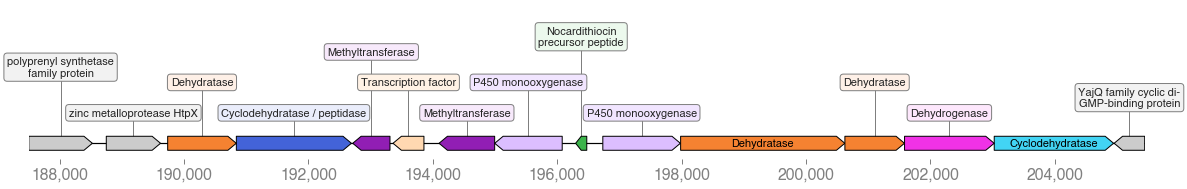

In [12]:
ax = plot_genes(nocardithiocin_context);

In [13]:
M_mazei_gff = parse_gff(nocardithiocin_folder / 'Methanosarcina mazei S-6' /  'GCF_000970205.1_ASM97020v1_genomic.gff')
M_mazei_gff.head()

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_011033260.1,NZ_CP009512.1,Protein Homology,CDS,620,1864,.,+,0,ID=cds-WP_011033260.1;Parent=gene-MSMAS_RS0000...,ORC1-type DNA replication protein
WP_011033259.1,NZ_CP009512.1,Protein Homology,CDS,2584,3144,.,+,0,ID=cds-WP_011033259.1;Parent=gene-MSMAS_RS0001...,flagellar hook-basal body complex protein FliE
WP_011033258.1,NZ_CP009512.1,Protein Homology,CDS,3342,3821,.,+,0,ID=cds-WP_011033258.1;Parent=gene-MSMAS_RS0001...,hypothetical protein
WP_011033257.1,NZ_CP009512.1,Protein Homology,CDS,3935,4708,.,+,0,ID=cds-WP_011033257.1;Parent=gene-MSMAS_RS0002...,sugar phosphate isomerase/epimerase
WP_011033256.1,NZ_CP009512.1,Protein Homology,CDS,5067,5549,.,-,0,ID=cds-WP_011033256.1;Parent=gene-MSMAS_RS0002...,gamma-glutamylcyclotransferase


In [14]:
putative_nocardithiocin = M_mazei_gff.loc['WP_011033557.1']

n_upstream = n_downstream = 9_000
contig_id = putative_nocardithiocin['contig_id']
start = max(putative_nocardithiocin['start'] - n_upstream, 1)
end = putative_nocardithiocin['end'] + n_downstream

putative_nocardithiocin_context = M_mazei_gff[
    (M_mazei_gff['contig_id'] == contig_id) &
    (M_mazei_gff['start'] >= start) &
    (M_mazei_gff['start'] < end) &
    (M_mazei_gff['end'] > start) &
    (M_mazei_gff['end'] <= end)
].copy()
putative_nocardithiocin_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_011033565.1,NZ_CP009512.1,Protein Homology,CDS,3779300,3779608,.,+,0,ID=cds-WP_011033565.1;Parent=gene-MSMAS_RS1623...,hypothetical protein
WP_048046818.1,NZ_CP009512.1,GeneMarkS-2+,CDS,3780098,3780289,.,-,0,ID=cds-WP_048046818.1;Parent=gene-MSMAS_RS1623...,hypothetical protein
WP_015411957.1,NZ_CP009512.1,Protein Homology,CDS,3780645,3780827,.,+,0,ID=cds-WP_015411957.1;Parent=gene-MSMAS_RS1624...,4Fe-4S binding protein
WP_011033563.1,NZ_CP009512.1,Protein Homology,CDS,3780924,3781952,.,+,0,ID=cds-WP_011033563.1;Parent=gene-MSMAS_RS1624...,aspartate-semialdehyde dehydrogenase
WP_011033562.1,NZ_CP009512.1,Protein Homology,CDS,3782167,3783357,.,-,0,ID=cds-WP_011033562.1;Parent=gene-MSMAS_RS1625...,nickel pincer cofactor biosynthesis protein LarC
WP_011033561.1,NZ_CP009512.1,Protein Homology,CDS,3783418,3784230,.,-,0,ID=cds-WP_011033561.1;Parent=gene-MSMAS_RS1625...,nickel pincer cofactor biosynthesis protein LarB
WP_011033560.1,NZ_CP009512.1,Protein Homology,CDS,3784557,3785753,.,-,0,ID=cds-WP_011033560.1;Parent=gene-MSMAS_RS1626...,aldo/keto reductase
WP_230633301.1,NZ_CP009512.1,Protein Homology,CDS,3785830,3786372,.,-,0,ID=cds-WP_230633301.1;Parent=gene-MSMAS_RS1626...,TetR/AcrR family transcriptional regulator
WP_226987745.1,NZ_CP009512.1,Protein Homology,CDS,3786676,3787257,.,-,0,ID=cds-WP_226987745.1;Parent=gene-MSMAS_RS1627...,DUF111 family protein


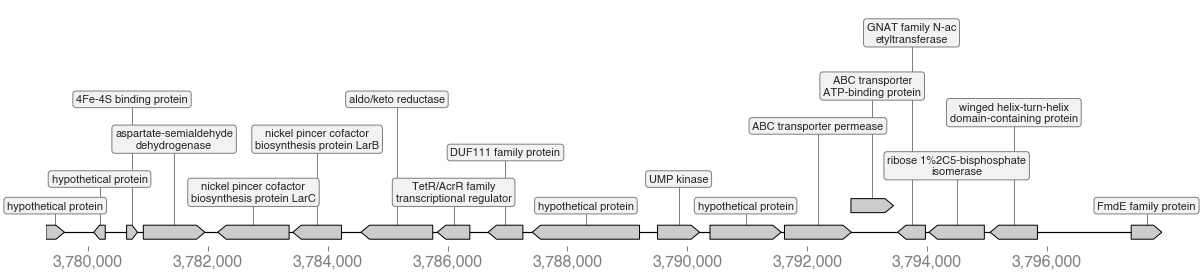

In [15]:
plot_genes(putative_nocardithiocin_context);